In [1]:
# PubMed Mini Scan (toy systematic scan) 
# pip install biopython pandas matplotlib scikit-learn

from Bio import Entrez
import pandas as pd
import re
from collections import Counter
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer

# 1) Configure Entrez (NCBI asks for an email; an API key is optional but recommended for heavier usage)
Entrez.email = "YOUR_EMAIL@domain.com"
# Entrez.api_key = "YOUR_NCBI_API_KEY"  # optional



### Helper functions

In [2]:

def pubmed_search(query: str, retmax: int = 50):
    handle = Entrez.esearch(db="pubmed", term=query, retmax=retmax, sort="relevance")
    res = Entrez.read(handle)
    handle.close()
    return res["IdList"]

def pubmed_fetch_details(pmids):
    # Fetch MEDLINE records for convenient parsing
    handle = Entrez.efetch(db="pubmed", id=",".join(pmids), rettype="medline", retmode="text")
    text = handle.read()
    handle.close()
    return text

def parse_medline_block(medline_text: str):
    """
    Minimal MEDLINE parser for a toy demo:
    - Captures PMID, TI (title), JT (journal), DP (date), AB (abstract), MH (MeSH)
    """
    records = []
    cur = {"MH": []}
    last_key = None

    for line in medline_text.splitlines():
        if not line.strip():
            continue

        # New field line (e.g., "PMID- 12345")
        m = re.match(r"^([A-Z]{2,4})\s*-\s*(.*)$", line)
        if m:
            key, val = m.group(1), m.group(2).strip()
            last_key = key

            if key == "PMID":
                # flush old record if it exists
                if "PMID" in cur:
                    records.append(cur)
                    cur = {"MH": []}
                cur["PMID"] = val
            elif key in {"TI", "JT", "DP", "AB"}:
                cur[key] = val
            elif key == "MH":
                cur["MH"].append(val)
            else:
                # ignore other fields for this mini notebook
                pass
        else:
            # Continuation line (starts with spaces)
            cont = line.strip()
            if last_key in {"TI", "AB"}:
                cur[last_key] = (cur.get(last_key, "") + " " + cont).strip()
            elif last_key == "MH":
                # occasionally MeSH can wrap; append to last MeSH term
                if cur["MH"]:
                    cur["MH"][-1] = (cur["MH"][-1] + " " + cont).strip()

    if "PMID" in cur:
        records.append(cur)

    df = pd.DataFrame(records)
    df["year"] = df["DP"].str.extract(r"(\d{4})").astype(float)
    df["mesh"] = df["MH"].apply(lambda xs: "; ".join(xs) if isinstance(xs, list) else "")
    df = df.rename(columns={"TI": "title", "JT": "journal", "AB": "abstract", "DP": "date"})
    return df[["PMID", "title", "journal", "date", "year", "abstract", "mesh"]]



Found 50 PMIDs


,PMID,title,journal,date,year,abstract,mesh
0,30874963,Metformin: Mechanisms in Human Obesity and Wei...,Current obesity reports,2019 Jun,2019.0,PURPOSE OF REVIEW: Metformin has multiple bene...,Aging/drug effects; Animals; Diabetes Mellitus...
1,35039672,Histone deacetylase 6 inhibition restores lept...,Nature metabolism,2022 Jan,2022.0,The adipose tissue-derived hormone leptin can ...,Adipose Tissue/drug effects/metabolism; Animal...
2,39424350,Effect of weight-maintaining ketogenic diet on...,BMJ open diabetes research & care,2024 Oct 18,2024.0,INTRODUCTION: Low carbohydrate ketogenic diets...,"Humans; *Diet, Ketogenic/methods; *Insulin Res..."
3,36950759,Impact of Intermittent Fasting on the Gut Micr...,Advanced biology,2023 Aug,2023.0,Obesity often results in severe negative healt...,Humans; Animals; *Obesity/microbiology/patholo...
4,37329216,Adipose Tissue Dysfunction in Polycystic Ovary...,The Journal of clinical endocrinology and meta...,2023 Dec 21,2023.0,PURPOSE: Polycystic ovary syndrome (PCOS) is a...,Humans; Female; Adult; *Polycystic Ovary Syndr...


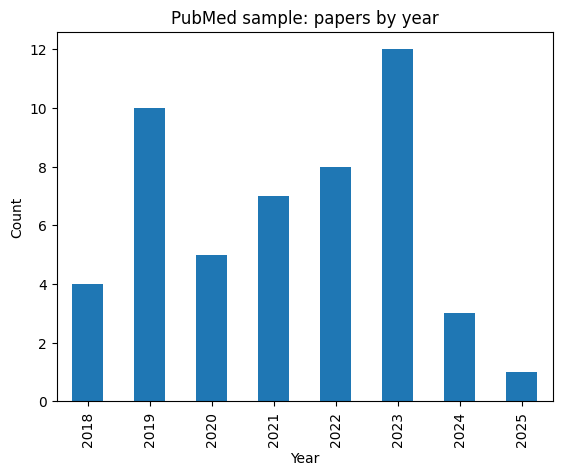

,term,mean_tfidf
23,obesity,0.202506
17,leptin,0.162841
15,insulin,0.150781
28,weight,0.137040
6,energy,0.129981
10,ghrelin,0.103830
19,metabolic,0.101763
18,loss,0.094804
2,associated,0.092619
29,weight loss,0.090901


Wrote: pubmed_sample.csv and pubmed_sample.json


In [3]:

QUERY = '("weight loss" OR "weight-loss" OR "diet-induced weight loss" OR "weight regain" OR "weight cycling" OR "adaptive thermogenesis" OR "metabolic adaptation" OR "energy expenditure") \
  AND \
  (obesity OR adiposity OR "body weight" OR "weight regulation") \
  AND \
  ( \
    biomarker* OR "molecular marker*" OR metabolomic* OR proteomic* OR transcriptomic* OR epigenetic* OR methylation OR "gene variant*" OR polymorphism* OR GWAS OR SNP* \
    OR leptin OR ghrelin OR insulin OR "insulin resistance" OR cortisol OR "HPA axis" OR inflammation OR cytokine* OR CRP \
    OR "allostatic load" OR stress OR sleep \
    OR exposom* OR "endocrine disruptor*" OR PFAS OR phthalate* OR bisphenol* OR "air pollution" \
    OR microbiome OR "gut microbiota" \
  ) \
) \
AND ("2018"[dp] : "2026"[dp])'
N = 50  # keep toy-sized for a portfolio demo

# 2) Run the workflow
pmids = pubmed_search(QUERY, retmax=N)
print(f"Found {len(pmids)} PMIDs")

medline_text = pubmed_fetch_details(pmids)
df = parse_medline_block(medline_text)

# 3) Quick EDA
display(df.head(5))

year_counts = df["year"].dropna().astype(int).value_counts().sort_index()
year_counts.plot(kind="bar")
plt.title("PubMed sample: papers by year")
plt.xlabel("Year")
plt.ylabel("Count")
plt.show()

# 4) Lightweight keyword signal (TF-IDF over titles+abstracts)
corpus = (df["title"].fillna("") + ". " + df["abstract"].fillna("")).tolist()
vectorizer = TfidfVectorizer(
    stop_words="english",
    max_features=30,
    ngram_range=(1, 2),
)
X = vectorizer.fit_transform(corpus)
top_terms = pd.Series(vectorizer.get_feature_names_out(), index=range(len(vectorizer.get_feature_names_out())))
tfidf_means = X.mean(axis=0).A1
top_tfidf = pd.DataFrame({"term": vectorizer.get_feature_names_out(), "mean_tfidf": tfidf_means}).sort_values("mean_tfidf", ascending=False)

display(top_tfidf.head(15))

# 5) Export a curated sample (your portfolio artifact)
out_csv = "pubmed_sample.csv"
out_json = "pubmed_sample.json"
df.to_csv(out_csv, index=False)
df.to_json(out_json, orient="records", indent=2)

print("Wrote:", out_csv, "and", out_json)

In [4]:
!pip -q install transformers sentence-transformers torch

In [5]:
import pandas as pd

df = pd.read_csv("pubmed_sample.csv")
df["text"] = (df["title"].fillna("") + ". " + df["abstract"].fillna("")).str.strip()
df = df[df["text"].str.len() > 50].copy()
df.head(2)

,PMID,title,journal,date,year,abstract,mesh,text
0,30874963,Metformin: Mechanisms in Human Obesity and Wei...,Current obesity reports,2019 Jun,2019.0,PURPOSE OF REVIEW: Metformin has multiple bene...,Aging/drug effects; Animals; Diabetes Mellitus...,Metformin: Mechanisms in Human Obesity and Wei...
1,35039672,Histone deacetylase 6 inhibition restores lept...,Nature metabolism,2022 Jan,2022.0,The adipose tissue-derived hormone leptin can ...,Adipose Tissue/drug effects/metabolism; Animal...,Histone deacetylase 6 inhibition restores lept...


In [6]:
from sentence_transformers import SentenceTransformer
import numpy as np

model = SentenceTransformer("sentence-transformers/all-MiniLM-L6-v2")  # small + fast
texts = df["text"].str.slice(0, 800).tolist()
emb = model.encode(texts, show_progress_bar=True, normalize_embeddings=True)
emb.shape

/Users/dominiero/opt/anaconda3/envs/py3.12/lib/python3.12/site-packages/sentence_transformers/cross_encoder/CrossEncoder.py:13: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from tqdm.autonotebook import tqdm, trange
Batches: 100%|██████████| 2/2 [00:02<00:00,  1.37s/it]


(50, 384)

In [7]:
# Save a small embedding sample for the portfolio
emb_df = pd.DataFrame(emb)
emb_df.insert(0, "PMID", df["PMID"].values)
emb_df.to_csv("pubmed_embeddings.csv", index=False)
print("Wrote pubmed_embeddings.csv")

Wrote pubmed_embeddings.csv


In [8]:
from sklearn.cluster import KMeans

k = 6  # toy number of clusters
km = KMeans(n_clusters=k, random_state=0, n_init="auto")
df["cluster"] = km.fit_predict(emb)

df[["PMID","year","journal","cluster","title"]].sort_values(["cluster","year"]).head(20)

/Users/dominiero/opt/anaconda3/envs/py3.12/lib/python3.12/site-packages/threadpoolctl.py:1214: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)


,PMID,year,journal,cluster,title
29,30641865,2019.0,Nutrients,0,Resveratrol and Its Human Metabolites-Effects ...
36,30728086,2019.0,Nutrition research reviews,0,"Seafood intake and the development of obesity,..."
27,35889827,2022.0,Nutrients,0,Implications of Resveratrol in Obesity and Ins...
10,32139381,2020.0,Diabetes care,1,Efficacy and Safety of Liraglutide 3.0 mg in I...
8,34749895,2021.0,The Nursing clinics of North America,1,Obesity and Sleep.
23,33200240,2021.0,Diabetologia,1,Brain JNK and metabolic disease.
7,34798121,2022.0,European journal of pharmacology,1,AgRP/NPY and POMC neurons in the arcuate nucle...
31,34953778,2022.0,Annales d'endocrinologie,1,Rare genetic causes of obesity: Diagnosis and ...
33,37787550,2023.0,Journal of the American Society of Nephrology ...,1,Central Adiposity Increases Risk of Kidney Sto...
12,29971406,2018.0,JAMA internal medicine,2,The Carbohydrate-Insulin Model of Obesity: Bey...


In [9]:
import numpy as np

centroids = km.cluster_centers_
# cosine similarity since embeddings were normalized
sims = emb @ centroids.T

rep_rows = []
for c in range(k):
    idx = np.argmax(sims[:, c])
    rep_rows.append((c, df.iloc[idx]["PMID"], df.iloc[idx]["title"]))
pd.DataFrame(rep_rows, columns=["cluster","PMID","representative_title"])

,cluster,PMID,representative_title
0,0,35889827,Implications of Resveratrol in Obesity and Ins...
1,1,34953778,Rare genetic causes of obesity: Diagnosis and ...
2,2,30874792,Ghrelin's Relationship to Blood Glucose.
3,3,31426593,The Short-Chain Fatty Acid Acetate in Body Wei...
4,4,33619380,Genome-wide discovery of genetic loci that unc...
5,5,31577926,Auto-Regulation of Leptin Neurobiology.


In [11]:
from transformers import pipeline

classifier = pipeline(
    "zero-shot-classification",
    model="facebook/bart-large-mnli",
    device=-1  
)

labels = [
    "exposomics / environmental exposure",
    "endocrine disruption (PFAS, phthalates, bisphenols)",
    "stress biology / allostatic load / HPA axis",
    "genetics / variants / GWAS",
    "epigenetics / methylation",
    "microbiome / gut microbiota",
    "metabolic adaptation / adaptive thermogenesis",
    "insulin resistance / metabolic syndrome",
    "inflammation / immune signaling"
]

def zshot(text):
    # keep the texts short(...ish) to avoid long inference times
    text = text[:1500]
    out = classifier(text, labels, multi_label=True)
    # keep top few
    pairs = list(zip(out["labels"], out["scores"]))
    pairs.sort(key=lambda x: x[1], reverse=True)
    return pairs[:4]

df["tags"] = df["text"].apply(zshot)
df[["PMID","title","tags"]].head(10)

'(ProtocolError('Connection aborted.', RemoteDisconnected('Remote end closed connection without response')), '(Request ID: 45a9e45d-6e00-43bd-9fa0-e587266633f4)')' thrown while requesting HEAD https://huggingface.co/facebook/bart-large-mnli/resolve/main/model.safetensors
Retrying in 1s [Retry 1/5].
'(MaxRetryError("HTTPSConnectionPool(host='huggingface.co', port=443): Max retries exceeded with url: /facebook/bart-large-mnli/resolve/main/model.safetensors (Caused by NewConnectionError('<urllib3.connection.HTTPSConnection object at 0x1529c7110>: Failed to establish a new connection: [Errno 8] nodename nor servname provided, or not known'))"), '(Request ID: 18f81fba-d16b-4f9b-a747-1cebf020bf12)')' thrown while requesting HEAD https://huggingface.co/facebook/bart-large-mnli/resolve/main/model.safetensors
Retrying in 2s [Retry 2/5].
'(MaxRetryError("HTTPSConnectionPool(host='huggingface.co', port=443): Max retries exceeded with url: /facebook/bart-large-mnli/resolve/main/model.safetensors (

ValueError: Could not load model facebook/bart-large-mnli with any of the following classes: (<class 'transformers.models.auto.modeling_auto.AutoModelForSequenceClassification'>, <class 'transformers.models.bart.modeling_bart.BartForSequenceClassification'>). See the original errors:

while loading with AutoModelForSequenceClassification, an error is thrown:
Traceback (most recent call last):
  File "/Users/dominiero/opt/anaconda3/envs/py3.12/lib/python3.12/site-packages/transformers/modeling_utils.py", line 1037, in _get_resolved_checkpoint_files
    resolved_archive_file = cached_file(pretrained_model_name_or_path, filename, **cached_file_kwargs)
                            ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/Users/dominiero/opt/anaconda3/envs/py3.12/lib/python3.12/site-packages/transformers/utils/hub.py", line 322, in cached_file
    file = cached_files(path_or_repo_id=path_or_repo_id, filenames=[filename], **kwargs)
           ^^^^^^^

In [ ]:
rows = []
for _, r in df.iterrows():
    for lab, sc in r["tags"]:
        rows.append({"PMID": r["PMID"], "label": lab, "score": sc})
tags_df = pd.DataFrame(rows).sort_values(["PMID","score"], ascending=[True, False])
tags_df.to_csv("pubmed_zero_shot_tags.csv", index=False)
print("Wrote pubmed_zero_shot_tags.csv")